# KMeans + Log Transform
**ShipmentSure — Predicting On-Time Delivery**

- Log transform to stabilize skewed cost/discount features before clustering
- KMeans clustering after scaling
- Interpret cluster characteristics before/after transformation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,C,Flight,2,5,306,6,high,M,45,3838,1
1,F,Ship,7,2,114,3,high,M,35,2710,1
2,B,Ship,7,2,215,7,medium,F,44,4152,0
3,A,Road,5,3,126,5,medium,M,54,2245,0
4,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Skewness before transformation
cols_to_transform = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']
print("Skewness BEFORE log transform:")
print(df[cols_to_transform].skew().round(3))

Skewness BEFORE log transform:
Cost_of_the_Product   -0.020
Discount_offered       0.035
Weight_in_gms         -0.059
dtype: float64


In [4]:
# Apply log transform
for col in cols_to_transform:
    df[f'log_{col}'] = np.log1p(df[col])

log_cols = [f'log_{col}' for col in cols_to_transform]
print("Skewness AFTER log transform:")
print(df[log_cols].skew().round(3))

Skewness AFTER log transform:
log_Cost_of_the_Product   -0.444
log_Discount_offered      -1.079
log_Weight_in_gms         -0.692
dtype: float64


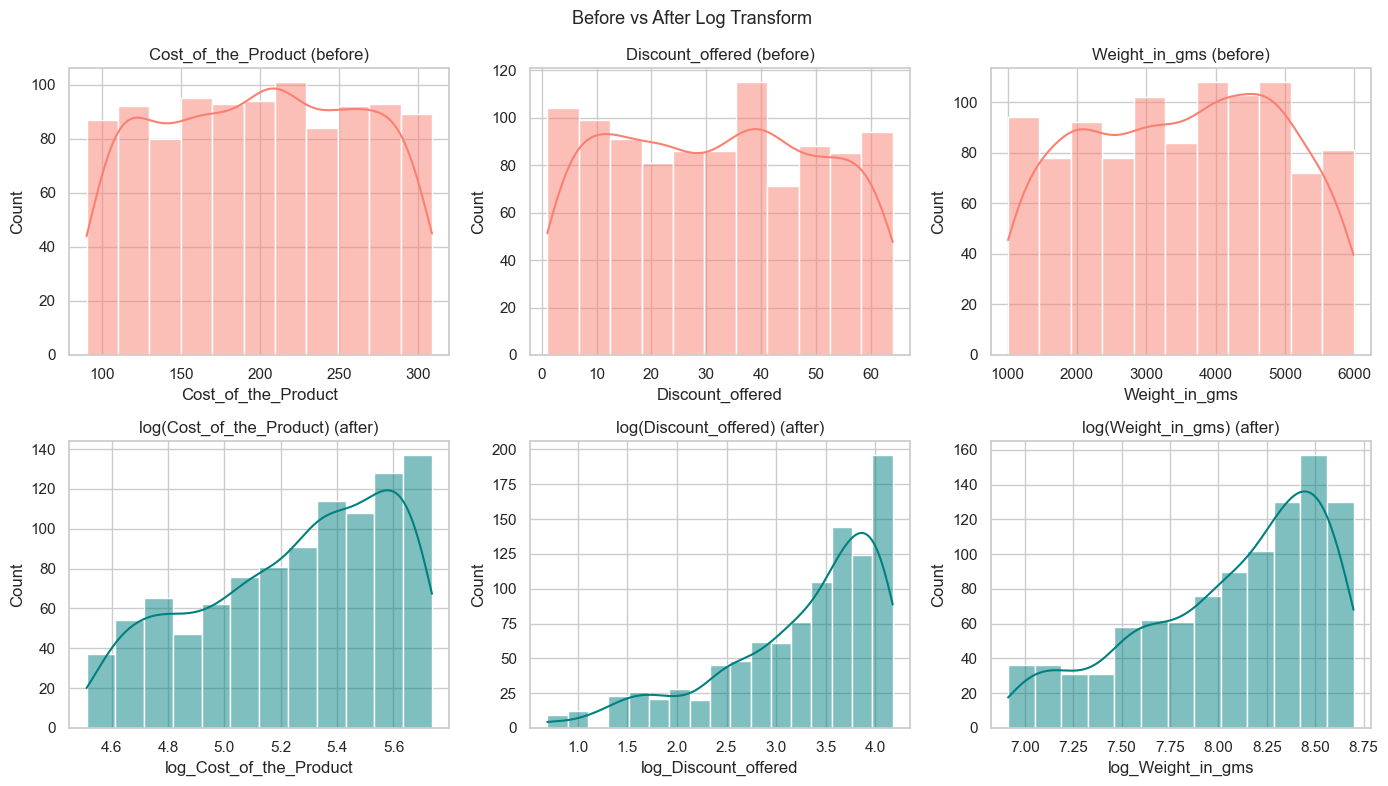

In [5]:
# Before/After comparison histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Before vs After Log Transform', fontsize=13)

for i, col in enumerate(cols_to_transform):
    sns.histplot(df[col], kde=True, ax=axes[0][i], color='salmon')
    axes[0][i].set_title(f'{col} (before)')

    sns.histplot(df[f'log_{col}'], kde=True, ax=axes[1][i], color='teal')
    axes[1][i].set_title(f'log({col}) (after)')

plt.tight_layout()
plt.show()

In [6]:
# KMeans on log-transformed features
scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(df[log_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_log_scaled)

print("Cluster distribution (after log transform):")
print(df['Cluster'].value_counts())

Cluster distribution (after log transform):
Cluster
0    470
1    313
2    217
Name: count, dtype: int64


S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [7]:
# Interpret clusters with describe
print("Cluster profile (original scale):")
df.groupby('Cluster')[cols_to_transform + ['Reached.on.Time_Y.N']].mean().round(3)

Cluster profile (original scale):


,Cost_of_the_Product,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Cluster,,,,
0,243.345,40.632,3525.221,0.509
1,131.300,35.946,3513.371,0.511
2,206.668,7.553,3432.599,0.488


C:\Users\rishi\AppData\Local\Temp\ipykernel_6232\3734588781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=col, ax=axes[i], palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_6232\3734588781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=col, ax=axes[i], palette='Set2')
C:\Users\rishi\AppData\Local\Temp\ipykernel_6232\3734588781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y=col, ax=axes[i], palette='Set2')


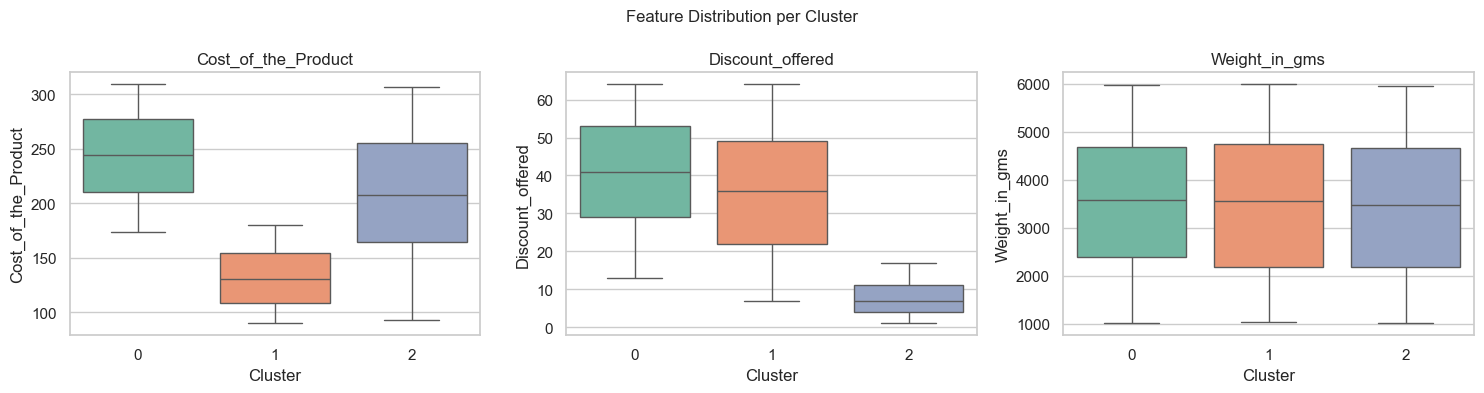

In [8]:
# Boxplots per cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distribution per Cluster', fontsize=12)

for i, col in enumerate(cols_to_transform):
    sns.boxplot(data=df, x='Cluster', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [9]:
# On-time rate per cluster
print("On-time delivery rate per cluster:")
print(df.groupby('Cluster')['Reached.on.Time_Y.N'].mean().round(3))

On-time delivery rate per cluster:
Cluster
0    0.509
1    0.511
2    0.488
Name: Reached.on.Time_Y.N, dtype: float64
